# 04 - Model Baseline

Notebook này triển khai các mô hình baseline: Logistic Regression, Decision Tree, Random Forest và SVM với 5-Fold Stratified Cross-Validation.

## 4.1 Load Data & Setup

Mục tiêu của phần này là nạp dữ liệu đã feature engineering, tách biến đầu vào/đầu ra, và xây dựng hàm đánh giá chung để dùng lại cho tất cả mô hình.

Các chỉ số đánh giá chính:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Sử dụng Stratified K-Fold giúp giữ tỉ lệ lớp gần như giống nhau ở mỗi fold, đảm bảo đánh giá ổn định hơn cho bài toán phân loại mất cân bằng.

In [1]:
# 4.1 Load data and define shared utilities
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
N_SPLITS = 5

data_path = Path("../data/processed/train_final.csv")
df = pd.read_csv(data_path)

target_col = "Depression"
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Target distribution (ratio):\n{y.value_counts(normalize=True).rename('ratio').round(4)}")

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model_cv(model, X_data, y_data, cv_strategy, model_name):
    """Run stratified CV and return fold-level and aggregated metrics."""
    fold_metrics = []

    for fold_idx, (train_idx, valid_idx) in enumerate(cv_strategy.split(X_data, y_data), start=1):
        estimator = clone(model)

        X_train_fold = X_data.iloc[train_idx]
        X_valid_fold = X_data.iloc[valid_idx]
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        estimator.fit(X_train_fold, y_train_fold)
        y_pred = estimator.predict(X_valid_fold)

        fold_metrics.append(
            {
                "model": model_name,
                "fold": fold_idx,
                "accuracy": accuracy_score(y_valid_fold, y_pred),
                "f1": f1_score(y_valid_fold, y_pred, zero_division=0),
                "precision": precision_score(y_valid_fold, y_pred, zero_division=0),
                "recall": recall_score(y_valid_fold, y_pred, zero_division=0),
            }
        )

    fold_df = pd.DataFrame(fold_metrics)
    summary_df = (
        fold_df[["accuracy", "f1", "precision", "recall"]]
        .agg(["mean", "std"])
        .T
        .reset_index()
        .rename(columns={"index": "metric"})
    )
    summary_df["mean_std"] = summary_df.apply(
        lambda row: f"{row['mean']:.4f} ± {row['std']:.4f}", axis=1
    )
    return fold_df, summary_df

def show_metric_summary(summary_df):
    """Create a compact summary table for notebook reporting."""
    return summary_df[["metric", "mean_std"]].rename(
        columns={"metric": "Metric", "mean_std": "Mean ± Std"}
    )

def metric_value(summary_df, metric_name, stat="mean"):
    """Extract one scalar metric from summary table."""
    return float(summary_df.loc[summary_df["metric"] == metric_name, stat].iloc[0])

display(df.head())

Dataset shape: (140700, 23)
Number of features: 22
Target distribution (ratio):
Depression
0    0.8183
1    0.1817
Name: ratio, dtype: float64


,Age,Working Professional or Student,CGPA,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Depression,Pressure,Satisfaction,has_cgpa,City_te,Profession_te,Degree_te,stress_load,wellbeing_index,stress_satisfaction_ratio,hours_pressure_ratio,poor_sleep,cgpa_pressure,risk_score,age_group
0,49,1,0.00,3,2,0,1,2.0,0,5.0,2.0,0,0.186035,0.047461,0.171802,10.0,2.5,1.666667,5.0,0,0.00,0,2
1,26,1,0.00,0,0,1,7,3.0,1,4.0,3.0,0,0.137782,0.055411,0.150835,12.0,1.5,1.000000,28.0,1,0.00,1,0
2,33,0,8.97,1,2,1,3,1.0,1,5.0,2.0,1,0.159042,0.534109,0.116610,5.0,1.5,1.666667,15.0,0,44.85,1,1
3,22,1,0.00,0,1,1,10,1.0,1,5.0,1.0,0,0.130731,0.053929,0.132338,5.0,0.5,2.500000,50.0,1,0.00,2,0
4,30,1,0.00,1,0,1,9,4.0,0,1.0,1.0,0,0.121875,0.053860,0.132338,4.0,1.0,0.500000,9.0,0,0.00,2,1


### Nhận xét 4.1

- Dataset sau feature engineering có **140,700 dòng** và **23 cột**; sau khi tách target còn **22 features** đầu vào.
- Phân phối lớp: `Depression=0` khoảng **81.83%**, `Depression=1` khoảng **18.17%** -> dữ liệu lệch lớp mức vừa.
- Việc dùng `StratifiedKFold (5 folds)` là phù hợp vì giữ tỉ lệ lớp ổn định giữa các fold, giúp so sánh mô hình công bằng.

## 4.2 Logistic Regression

Logistic Regression là mô hình tuyến tính cho phân loại nhị phân. Xác suất dự đoán được tính bởi hàm sigmoid:

$$\hat{y} = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

Hàm mất mát Binary Cross-Entropy:

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

Vì LR nhạy với thang đo đặc trưng nên cần chuẩn hóa bằng `StandardScaler` trước khi huấn luyện.

In [2]:
# 4.2 Logistic Regression with feature scaling
log_reg_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

lr_fold_df, lr_summary_df = evaluate_model_cv(
    model=log_reg_model,
    X_data=X,
    y_data=y,
    cv_strategy=cv,
    model_name="Logistic Regression",
)

print("Fold-level metrics for Logistic Regression:")
display(lr_fold_df)

print("Aggregated metrics (mean ± std):")
display(show_metric_summary(lr_summary_df))

Fold-level metrics for Logistic Regression:


,model,fold,accuracy,f1,precision,recall
0,Logistic Regression,1,0.937242,0.823717,0.841182,0.806963
1,Logistic Regression,2,0.935785,0.818629,0.840825,0.797575
2,Logistic Regression,3,0.938699,0.827310,0.847416,0.808136
3,Logistic Regression,4,0.940370,0.832435,0.850612,0.815018
4,Logistic Regression,5,0.935928,0.819501,0.839590,0.800352


Aggregated metrics (mean ± std):


,Metric,Mean ± Std
0,accuracy,0.9376 ± 0.0019
1,f1,0.8243 ± 0.0057
2,precision,0.8439 ± 0.0048
3,recall,0.8056 ± 0.0069


### Nhận xét 4.2

- Logistic Regression đạt `Accuracy = 0.9376 ± 0.0019`, `F1 = 0.8243 ± 0.0057`, `Precision = 0.8439 ± 0.0048`, `Recall = 0.8056 ± 0.0069`.
- Độ lệch chuẩn thấp ở cả 4 metric cho thấy mô hình ổn định qua 5 folds.
- `Precision` cao hơn `Recall`, nghĩa là mô hình dự đoán dương tính khá thận trọng (ít false positive hơn, nhưng vẫn bỏ sót một phần ca dương tính).

## 4.3 Decision Tree

Decision Tree chia dữ liệu theo các điều kiện nhị phân để giảm độ hỗn loạn của nút.

Hai tiêu chí phổ biến:

$$\text{Gini}(t) = 1 - \sum_{k} p_k^2$$

$$\text{Entropy}(t) = -\sum_{k} p_k \log_2(p_k)$$

Trong notebook baseline này, ta so sánh nhiều giá trị `max_depth` để tìm điểm cân bằng giữa underfitting và overfitting.

In [3]:
# 4.3 Decision Tree depth comparison
depth_candidates = [5, 10, 15, None]
dt_cv_outputs = {}
dt_comparison_rows = []

for depth in depth_candidates:
    dt_model = DecisionTreeClassifier(
        max_depth=depth,
        criterion="gini",
        random_state=RANDOM_STATE,
    )

    fold_df, summary_df = evaluate_model_cv(
        model=dt_model,
        X_data=X,
        y_data=y,
        cv_strategy=cv,
        model_name=f"Decision Tree (max_depth={depth})",
    )

    dt_cv_outputs[depth] = {"fold": fold_df, "summary": summary_df}
    dt_comparison_rows.append(
        {
            "max_depth": "None" if depth is None else depth,
            "accuracy_mean": metric_value(summary_df, "accuracy", "mean"),
            "accuracy_std": metric_value(summary_df, "accuracy", "std"),
            "f1_mean": metric_value(summary_df, "f1", "mean"),
            "precision_mean": metric_value(summary_df, "precision", "mean"),
            "recall_mean": metric_value(summary_df, "recall", "mean"),
        }
    )

dt_depth_comparison_df = pd.DataFrame(dt_comparison_rows).sort_values(
    by="accuracy_mean", ascending=False
).reset_index(drop=True)

best_depth_label = dt_depth_comparison_df.loc[0, "max_depth"]
best_depth = None if best_depth_label == "None" else int(best_depth_label)
best_dt_summary_df = dt_cv_outputs[best_depth]["summary"]

print("Depth comparison table:")
display(dt_depth_comparison_df)

print(f"Best Decision Tree depth: {best_depth_label}")
display(show_metric_summary(best_dt_summary_df))

Depth comparison table:


,max_depth,accuracy_mean,accuracy_std,f1_mean,precision_mean,recall_mean
0,10,0.929225,0.001013,0.801131,0.818486,0.784605
1,5,0.923454,0.001660,0.783209,0.808201,0.761492
2,15,0.916070,0.001266,0.767105,0.773741,0.760668
3,None,0.904172,0.000941,0.737760,0.733761,0.741816


Best Decision Tree depth: 10


,Metric,Mean ± Std
0,accuracy,0.9292 ± 0.0010
1,f1,0.8011 ± 0.0038
2,precision,0.8185 ± 0.0059
3,recall,0.7846 ± 0.0101


### Nhận xét 4.3

- So sánh theo `max_depth` cho thấy `max_depth=10` tốt nhất: `Accuracy = 0.9292 ± 0.0010`, `F1 = 0.8011 ± 0.0038`.
- `max_depth=5` cho kết quả thấp hơn (`Accuracy ≈ 0.9235`) -> có xu hướng underfitting.
- Khi tăng sâu hơn (`max_depth=15` và `None`), hiệu năng giảm (`0.9161` và `0.9042`) -> dấu hiệu overfitting, nên cây quá sâu không phù hợp cho baseline.

## 4.4 Random Forest

Random Forest là ensemble của nhiều cây quyết định huấn luyện trên các bootstrap samples khác nhau. Dự đoán cuối cùng theo cơ chế bỏ phiếu đa số:

$$\hat{y} = \text{majority\_vote}(h_1(\mathbf{x}), h_2(\mathbf{x}), \ldots, h_T(\mathbf{x}))$$

Bagging giúp giảm phương sai so với một cây đơn lẻ, từ đó thường tổng quát hóa tốt hơn trên dữ liệu mới.

Random Forest parameter comparison:


,n_estimators,accuracy_mean,accuracy_std,f1_mean,precision_mean,recall_mean
0,200,0.936439,0.001441,0.820817,0.841476,0.801150
1,100,0.936198,0.001669,0.819870,0.841825,0.799038


Best Random Forest n_estimators: 200


,Metric,Mean ± Std
0,accuracy,0.9364 ± 0.0014
1,f1,0.8208 ± 0.0039
2,precision,0.8415 ± 0.0049
3,recall,0.8011 ± 0.0032


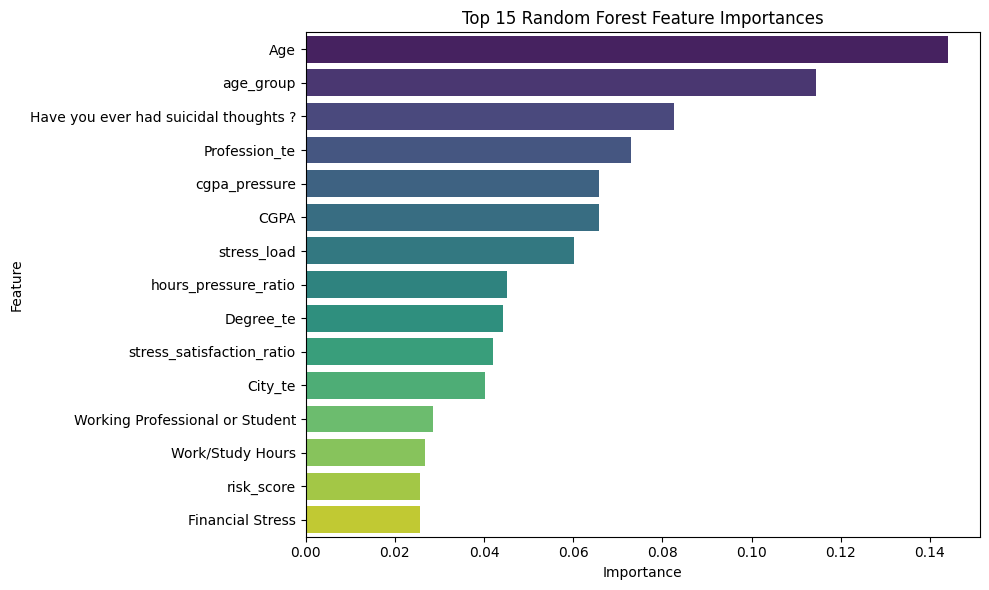

,feature,importance
0,Age,0.144023
1,age_group,0.114378
2,Have you ever had suicidal thoughts ?,0.082499
3,Profession_te,0.072892
4,cgpa_pressure,0.065807
5,CGPA,0.065766
6,stress_load,0.060201
7,hours_pressure_ratio,0.045219
8,Degree_te,0.044144
9,stress_satisfaction_ratio,0.042043


In [4]:
# 4.4 Random Forest baseline and feature importance
rf_n_estimators_candidates = [100, 200]
rf_cv_outputs = {}
rf_comparison_rows = []

for n_trees in rf_n_estimators_candidates:
    rf_model = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    fold_df, summary_df = evaluate_model_cv(
        model=rf_model,
        X_data=X,
        y_data=y,
        cv_strategy=cv,
        model_name=f"Random Forest (n_estimators={n_trees})",
    )

    rf_cv_outputs[n_trees] = {"fold": fold_df, "summary": summary_df}
    rf_comparison_rows.append(
        {
            "n_estimators": n_trees,
            "accuracy_mean": metric_value(summary_df, "accuracy", "mean"),
            "accuracy_std": metric_value(summary_df, "accuracy", "std"),
            "f1_mean": metric_value(summary_df, "f1", "mean"),
            "precision_mean": metric_value(summary_df, "precision", "mean"),
            "recall_mean": metric_value(summary_df, "recall", "mean"),
        }
    )

rf_comparison_df = pd.DataFrame(rf_comparison_rows).sort_values(
    by="accuracy_mean", ascending=False
).reset_index(drop=True)

best_n_estimators = int(rf_comparison_df.loc[0, "n_estimators"])
best_rf_summary_df = rf_cv_outputs[best_n_estimators]["summary"]

print("Random Forest parameter comparison:")
display(rf_comparison_df)

print(f"Best Random Forest n_estimators: {best_n_estimators}")
display(show_metric_summary(best_rf_summary_df))

# Fit the best Random Forest on full training data to inspect feature importances
best_rf_model_full = RandomForestClassifier(
    n_estimators=best_n_estimators,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
best_rf_model_full.fit(X, y)

rf_feature_importance_df = (
    pd.DataFrame(
        {"feature": X.columns, "importance": best_rf_model_full.feature_importances_}
    )
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

top_k = 15
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rf_feature_importance_df.head(top_k),
    x="importance",
    y="feature",
    palette="viridis",
)
plt.title(f"Top {top_k} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(rf_feature_importance_df.head(top_k))

### Nhận xét 4.4

- So sánh `n_estimators` cho thấy cấu hình **200 cây** tốt hơn nhẹ so với 100 cây (`Accuracy = 0.9364` so với `0.9362`).
- Với cấu hình tốt nhất (`n_estimators=200`): `Accuracy = 0.9364 ± 0.0014`, `F1 = 0.8208 ± 0.0039`, `Precision = 0.8415 ± 0.0049`, `Recall = 0.8011 ± 0.0032`.
- Feature importance nổi bật: `Age` (~0.144), `age_group` (~0.114), `Have you ever had suicidal thoughts ?` (~0.082), `Profession_te` (~0.073), `cgpa_pressure` và `CGPA` (~0.066). Điều này phù hợp với insight từ EDA/Feature Engineering về vai trò của tuổi, tín hiệu tự sát và áp lực học tập-nghề nghiệp.

## 4.5 Support Vector Machine (SVM)

SVM tìm siêu phẳng phân tách với biên lớn nhất (maximum margin). Bài toán tối ưu dạng hard-margin:

$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{s.t.} \quad y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1$$

Do SVM có độ phức tạp tính toán cao với dữ liệu lớn, notebook này dùng chiến lược lấy mẫu phân tầng tối đa 30,000 dòng để đảm bảo thời gian chạy hợp lý.

In [5]:
# 4.5 SVM with optional subsampling for computational efficiency
MAX_SVM_SAMPLES = 30000

if len(X) > MAX_SVM_SAMPLES:
    X_svm, _, y_svm, _ = train_test_split(
        X,
        y,
        train_size=MAX_SVM_SAMPLES,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    print(f"SVM uses a stratified subset of {len(X_svm):,} samples out of {len(X):,}.")
else:
    X_svm, y_svm = X.copy(), y.copy()
    print(f"SVM uses the full dataset with {len(X_svm):,} samples.")

svm_kernels = ["linear", "rbf"]
svm_cv_outputs = {}
svm_comparison_rows = []

for kernel_name in svm_kernels:
    svm_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", SVC(kernel=kernel_name, C=1.0, gamma="scale")),
        ]
    )

    fold_df, summary_df = evaluate_model_cv(
        model=svm_model,
        X_data=X_svm,
        y_data=y_svm,
        cv_strategy=cv,
        model_name=f"SVM ({kernel_name})",
    )

    svm_cv_outputs[kernel_name] = {"fold": fold_df, "summary": summary_df}
    svm_comparison_rows.append(
        {
            "kernel": kernel_name,
            "accuracy_mean": metric_value(summary_df, "accuracy", "mean"),
            "accuracy_std": metric_value(summary_df, "accuracy", "std"),
            "f1_mean": metric_value(summary_df, "f1", "mean"),
            "precision_mean": metric_value(summary_df, "precision", "mean"),
            "recall_mean": metric_value(summary_df, "recall", "mean"),
        }
    )

svm_comparison_df = pd.DataFrame(svm_comparison_rows).sort_values(
    by="accuracy_mean", ascending=False
).reset_index(drop=True)

best_kernel = svm_comparison_df.loc[0, "kernel"]
best_svm_summary_df = svm_cv_outputs[best_kernel]["summary"]

print("SVM kernel comparison:")
display(svm_comparison_df)

print(f"Best SVM kernel: {best_kernel}")
display(show_metric_summary(best_svm_summary_df))

SVM uses a stratified subset of 30,000 samples out of 140,700.
SVM kernel comparison:


,kernel,accuracy_mean,accuracy_std,f1_mean,precision_mean,recall_mean
0,linear,0.9367,0.002126,0.822980,0.836566,0.809943
1,rbf,0.9359,0.002516,0.818687,0.842223,0.796550


Best SVM kernel: linear


,Metric,Mean ± Std
0,accuracy,0.9367 ± 0.0021
1,f1,0.8230 ± 0.0065
2,precision,0.8366 ± 0.0075
3,recall,0.8099 ± 0.0120


### Nhận xét 4.5

- SVM được huấn luyện trên **subset phân tầng 30,000 mẫu** (từ 140,700 mẫu) để đảm bảo thời gian tính toán hợp lý.
- Kernel `linear` tốt hơn `rbf` về Accuracy/F1: `Accuracy = 0.9367 ± 0.0021`, `F1 = 0.8230 ± 0.0065`.
- `rbf` có `Precision` nhỉnh hơn (`0.8422` so với `0.8366`) nhưng `Recall` thấp hơn (`0.7966` so với `0.8099`), nên tổng thể baseline chọn `linear` là hợp lý.

## 4.6 Bảng So Sánh Baseline

Phần này tổng hợp mô hình tốt nhất của từng họ thuật toán vào một bảng chung theo định dạng yêu cầu: Accuracy (mean ± std), F1, Precision, Recall.

Mục tiêu là xác định baseline mạnh nhất để làm mốc so sánh với XGBoost và LightGBM ở notebook 05.

Final baseline comparison table:


,Model,Accuracy (mean ± std),F1,Precision,Recall
0,Logistic Regression,0.9376 ± 0.0019,0.824318,0.843925,0.805609
1,SVM (kernel=linear),0.9367 ± 0.0021,0.822980,0.836566,0.809943
2,Random Forest (n_estimators=200),0.9364 ± 0.0014,0.820817,0.841476,0.801150
3,Decision Tree (max_depth=10),0.9292 ± 0.0010,0.801131,0.818486,0.784605


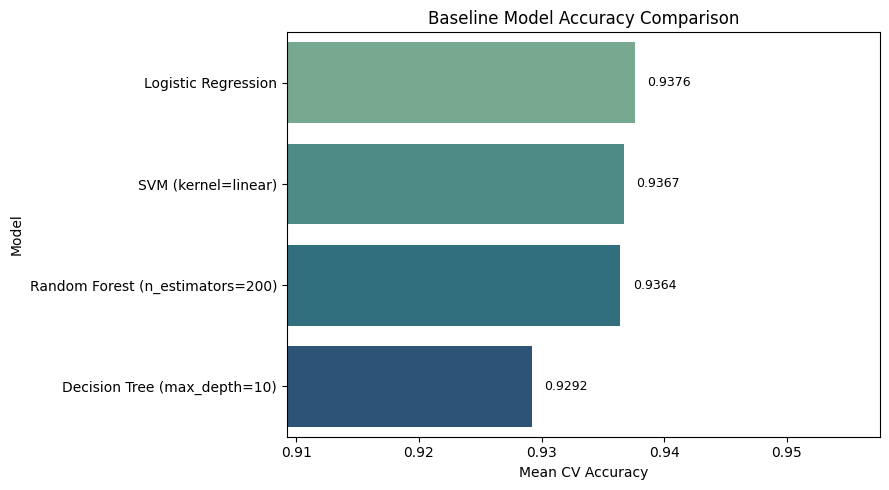

Best baseline model by CV accuracy: Logistic Regression


In [6]:
# 4.6 Baseline model comparison table
baseline_rows = [
    {
        "Model": "Logistic Regression",
        "Accuracy_mean": metric_value(lr_summary_df, "accuracy", "mean"),
        "Accuracy_std": metric_value(lr_summary_df, "accuracy", "std"),
        "F1_mean": metric_value(lr_summary_df, "f1", "mean"),
        "Precision_mean": metric_value(lr_summary_df, "precision", "mean"),
        "Recall_mean": metric_value(lr_summary_df, "recall", "mean"),
    },
    {
        "Model": f"Decision Tree (max_depth={best_depth_label})",
        "Accuracy_mean": metric_value(best_dt_summary_df, "accuracy", "mean"),
        "Accuracy_std": metric_value(best_dt_summary_df, "accuracy", "std"),
        "F1_mean": metric_value(best_dt_summary_df, "f1", "mean"),
        "Precision_mean": metric_value(best_dt_summary_df, "precision", "mean"),
        "Recall_mean": metric_value(best_dt_summary_df, "recall", "mean"),
    },
    {
        "Model": f"Random Forest (n_estimators={best_n_estimators})",
        "Accuracy_mean": metric_value(best_rf_summary_df, "accuracy", "mean"),
        "Accuracy_std": metric_value(best_rf_summary_df, "accuracy", "std"),
        "F1_mean": metric_value(best_rf_summary_df, "f1", "mean"),
        "Precision_mean": metric_value(best_rf_summary_df, "precision", "mean"),
        "Recall_mean": metric_value(best_rf_summary_df, "recall", "mean"),
    },
    {
        "Model": f"SVM (kernel={best_kernel})",
        "Accuracy_mean": metric_value(best_svm_summary_df, "accuracy", "mean"),
        "Accuracy_std": metric_value(best_svm_summary_df, "accuracy", "std"),
        "F1_mean": metric_value(best_svm_summary_df, "f1", "mean"),
        "Precision_mean": metric_value(best_svm_summary_df, "precision", "mean"),
        "Recall_mean": metric_value(best_svm_summary_df, "recall", "mean"),
    },
]

baseline_summary_df = pd.DataFrame(baseline_rows).sort_values(
    by="Accuracy_mean", ascending=False
).reset_index(drop=True)

baseline_summary_df["Accuracy (mean ± std)"] = baseline_summary_df.apply(
    lambda row: f"{row['Accuracy_mean']:.4f} ± {row['Accuracy_std']:.4f}", axis=1
)

report_table_df = baseline_summary_df[
    ["Model", "Accuracy (mean ± std)", "F1_mean", "Precision_mean", "Recall_mean"]
].rename(
    columns={
        "F1_mean": "F1",
        "Precision_mean": "Precision",
        "Recall_mean": "Recall",
    }
)

print("Final baseline comparison table:")
display(report_table_df)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=baseline_summary_df,
    x="Accuracy_mean",
    y="Model",
    palette="crest",
)
plt.title("Baseline Model Accuracy Comparison")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Model")
plt.xlim(
    max(0.0, baseline_summary_df["Accuracy_mean"].min() - 0.02),
    min(1.0, baseline_summary_df["Accuracy_mean"].max() + 0.02),
)
for idx, row in baseline_summary_df.iterrows():
    plt.text(
        row["Accuracy_mean"] + 0.001,
        idx,
        f"{row['Accuracy_mean']:.4f}",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

best_model_name = baseline_summary_df.loc[0, "Model"]
print(f"Best baseline model by CV accuracy: {best_model_name}")

### Nhận xét

- Xếp hạng theo Accuracy trung bình: **Logistic Regression (0.9376)** > **SVM-linear (0.9367)** > **Random Forest-200 (0.9364)** > **Decision Tree-10 (0.9292)**.
- Theo output hiện tại, mô hình baseline tốt nhất theo tiêu chí Accuracy là **Logistic Regression**; đồng thời model này cũng có `F1` cao nhất (`0.8243`) và `Precision` cao nhất (`0.8439`).
- Nếu ưu tiên giảm bỏ sót ca dương tính (tăng Recall), `SVM-linear` đang có `Recall` cao nhất (`0.8099`) dù Accuracy/F1 thấp hơn nhẹ; đây là trade-off cần nêu rõ khi báo cáo.